<a href="https://colab.research.google.com/github/LucasCabra7/precos-combustiveis-brasil-2015-2025/blob/developer%2Fbruno/Grupo_4_An%C3%A1lise_Explorat%C3%B3ria_e_Modelagem_Preditiva_dos_Pre%C3%A7os_de_Combust%C3%ADveis_no_Brasil_(2015%E2%80%932025).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Exploratória e Modelagem Preditiva dos Preços de Combustíveis no Brasil (2015–2025)



## 1. Descrição do Dataset

O presente projeto tem como objetivo analisar e compreender o comportamento dos preços de combustíveis no Brasil ao longo do tempo, utilizando dados públicos disponibilizados pela Agência Nacional do Petróleo, Gás Natural e Biocombustíveis (ANP).

[O conjunto de dados utilizado](https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/serie-historica-de-precos-de-combustiveis) consiste na série histórica de preços de combustíveis, contendo informações coletadas semanalmente em diversos postos distribuídos por estados e municípios brasileiros.

A base de dados inclui variáveis relevantes como localização geográfica (estado e município), tipo de combustível (gasolina, etanol, diesel, entre outros), datas de coleta e valores de compra e venda.

Para este estudo, foi selecionado o período de [**2015 a 2025** para o Dataset de estudo](https://drive.google.com/file/d/1HSjbMjqx4OD4beNF-mkqOMiha7mFKUl6/view?usp=sharing), por apresentar maior consistência nos dados e englobar eventos econômicos significativos que impactaram diretamente os preços dos combustíveis, como a crise econômica brasileira, a greve dos caminhoneiros em 2018 e a pandemia de COVID-19 em 2020.


* 2016 - Crise econômica do Brasil
* 2018 - Greve dos Caminhoneiros (impacto direto no combustível)
* 2020 - Pandemia (Covid-19)
* 2022 - Alta global do combustível

---


O conjunto de dados consolidado possui **9889848** instâncias (linhas) e **17** atributos (colunas). As variáveis estão divididas em tipos distintos: categóricas (como estado, município, produto e bandeira), numéricas contínuas (como valor de compra e valor de venda) e temporais (data da coleta).

Do ponto de vista prático, a compreensão desses dados permite aplicações como a previsão de custos operacionais para o setor de transporte e o monitoramento de anomalias mercadológicas.

Com base nesse contexto, o estudo configura-se como um problema de Regressão / Classificação, visto que o objetivo futuro da modelagem será prever o valor contínuo do combustível nas bombas / categorizar a tendência do mercado como alta, baixa ou estável.



## 2. Estruturação do Projeto

#### 2.1. Importações

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#### 2.2. Caminho para o Dataset e correções

In [6]:
import os

# Detecta automaticamente se está no Colab ou VS Code
try:
    from google.colab import drive
    drive.mount('/content/drive')
    caminho_dataset = '/content/drive/MyDrive/Projeto - Ciências de Dados (Grupo 4)/Dataset 2015 - 2025 (Separados)/Dataset_Completo_2015_2025.csv'
    print("Rodando no Google Colab")
except ImportError:
    # Caminho local para VS Code
    caminho_dataset = os.path.join(os.path.dirname('__file__'), 'data', 'Dataset_Completo_2015_2025.csv')
    print("Rodando no VS Code")

data_Frame = pd.read_csv(caminho_dataset, sep=';', low_memory=False)
data_Frame['Valor de Venda'] = data_Frame['Valor de Venda'].str.replace(',', '.').astype(float)

print(f"Dataset carregado! Total de linhas: {len(data_Frame)}")

Rodando no VS Code
Dataset carregado! Total de linhas: 9889848


## 3. Análises Estatísticas Descritivas





### 3.1.0 Análise Exploratória Inicial do Dataset

Análise exploratória Inicial com o objetivo de compreender a estrutura e os principais elementos da base de dados utilizada.

O dataset apresenta informações relacionadas à comercialização de combustíveis no Brasil no período de 2015 a 2025.

Entre as variáveis analisadas, destacam-se:

* Produto: identifica o tipo de combustível comercializado, sendo os principais gasolina, etanol, diesel e GNV;
* Município e Região: permitem a análise geográfica dos dados, evidenciando a distribuição espacial das observações;
* Unidade de Medida: associada ao tipo de combustível, indicando a forma de comercialização (por exemplo, litros ou metros cúbicos);
* Bandeira: representa a marca ou distribuidora associada ao posto de combustíveis.

A análise das frequências dos produtos revelou quais combustíveis possuem maior representatividade na base. Além disso, a distribuição dos municípios por região permitiu identificar a cobertura geográfica da pesquisa.


In [ ]:
print("\n ---- VISÃO GERAL DO DATASET ----\n")

print("Dimensões do dataset:")
print(f"Linhas: {data_Frame.shape[0]}")
print(f"Colunas: {data_Frame.shape[1]}")

print("\n Principais Features:")
display(data_Frame.columns)

print("\n Principais produtos:")
display(data_Frame['Produto'].value_counts())

print("\nMunicípios por Região:")
municipios_regiao = (
    data_Frame[['Municipio', 'Regiao - Sigla']]
    .drop_duplicates()
    .value_counts('Regiao - Sigla')
)
display(municipios_regiao)

print("\nUnidades de medida por produto:")
unidade_produto = (
    data_Frame[['Produto', 'Unidade de Medida']]
    .drop_duplicates()
    .sort_values(by='Produto')
)
display(unidade_produto)

print("\nPrincipais bandeiras:")
display(data_Frame['Bandeira'].value_counts().head(10))

### 3.2.0 Análises bivariadas por meio de estatísticas descritivas agrupadas sobre os dados brutos

* A análise dos dados brutos em pares de variáveis nos ajuda a entender como elas se relacionam entre si. Ao calcular a média dos preços por região ou município, conseguimos identificar diferenças importantes entre os locais. Isso permite observar padrões geográficos claros e entender como fatores regionais podem influenciar os preços dos combustíveis.



#### 3.2.1. Estatísticas Descritivas Brutas por Regiões Brasileiras

Nesta etapa, analisamos as frequências absoluta (numérica) e relativa (percentual) das regiões brasileiras presentes no dataset, considerando o período de 2015 a 2025.

O objetivo é identificar quais regiões possuem maior representatividade na base de dados, permitindo avaliar possíveis desequilíbrios amostrais (desbalanceamento de classes) entre as regiões. Esse tipo de análise é fundamental, pois a predominância de determinadas regiões pode influenciar os resultados e interpretações das análises subsequentes.

As regiões brasileiras consideradas na base são:

* **N – Norte**
* **NE – Nordeste**
* **SE – Sudeste**
* **S – Sul**
* **CO – Centro-Oeste**

In [ ]:
print("\n FREQUÊNCIA ABSOLUTA DAS REGIÕES \n")
frequencia_regiao_sigla = data_Frame['Regiao - Sigla'].value_counts()
display(frequencia_regiao_sigla)

print(" ")

print("\n FREQUÊNCIA PERCENTUAL DAS REGIÕES \n")
frequencia_regiao_sigla_percentual = (
    data_Frame['Regiao - Sigla']
    .value_counts(normalize=True)
    .round(4) * 100
)
display(frequencia_regiao_sigla_percentual)


#### 3.2.2 Estatísticas Descritivas Brutas das Regiões Brasileiras por Produto

Analisamos as frequências absoluta (numérica) e relativa (percentual) das regiões brasileiras presentes no dataset em relação ao Combustível (Produto), considerando o período de 2015 a 2025.

O objetivo é identificar quais regiões possuem maior representatividade por Produto na base de dados, permitindo avaliar possíveis desequilíbrios amostrais (desbalanceamento de classes) entre as regiões.

---

As regiões brasileiras consideradas na base são:

* **N – Norte**
* **NE – Nordeste**
* **SE – Sudeste**
* **S – Sul**
* **CO – Centro-Oeste**

Os produtos considerados na base são:
* Gasolina Comum
* Gasolina Aditivada
* Etanol
* Diesel
* Diesel S10
* GNV (Gás Natural Veicular)

In [ ]:
print("\n FREQUÊNCIA ABSOLUTA DAS REGIÕES POR PRODUTO \n")
frequencia_regiao_por_produto = (
    data_Frame
    .groupby(['Produto', 'Regiao - Sigla'])
    .size()
    .unstack(fill_value=0)
)
display(frequencia_regiao_por_produto)

print(" ")

print("\n FREQUÊNCIA PERCENTUAL DAS REGIÕES POR PRODUTO \n")
frequencia_regiao_por_produto_percentual = (
    data_Frame
    .groupby(['Produto', 'Regiao - Sigla'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: (x / x.sum()) * 100, axis=1)
    .round(2)
)
display(frequencia_regiao_por_produto_percentual)

#### 3.2.3. Estatísticas Descritivas Brutas do Valor de Venda por Tipo de Combustível (Produto)

Nesta etapa, analisamos o preço médio de venda dos combustíveis no período de 2015 a 2025, por tipo de produto e por estado brasileiro.

O objetivo é apresentar uma análise descritiva bruta, permitindo observar o comportamento dos preços ao longo do tempo e identificar possíveis variações regionais entre os estados.

É importante destacar que esta análise não considera fatores econômicos externos ou ajustes inflacionários, como o IPCA (Índice Nacional de Preços ao Consumidor Amplo). Dessa forma, os valores apresentados refletem os preços nominais praticados no período, sem correções monetárias.

Essa abordagem fornece uma visão inicial do cenário nacional de preços de combustíveis.

In [ ]:

status_produto_por_combustivel = (
    data_Frame
    .groupby(['Produto', 'Estado - Sigla'])['Valor de Venda']
    .describe()
    .round(2)
)

for produto in status_produto_por_combustivel.index.levels[0]:
    print(f"\n ESTATÍSTICAS PARA {produto} \n")
    display(status_produto_por_combustivel.loc[produto])


#### 3.2.4. Estatísticas Descritivas Brutas por Tipo de Combustível (Produto) com Ranking dos Municípios Mais Caros e Mais Baratos

Nesta etapa, analisamos o preço médio bruto de venda dos combustíveis nos municípios brasileiros, considerando o período de 2015 a 2025.

A análise é segmentada por tipo de combustível (produto) e tem como objetivo identificar os 10 municípios com maiores preços médios e os 10 com menores preços médios, permitindo uma comparação média e direta entre diferentes localidades dentro de cada categoria de combustível.

Os valores apresentados correspondem a médias históricas do período analisado, caracterizando uma análise descritiva bruta, sem a aplicação de ajustes inflacionários ou controle por variáveis econômicas, como o IPCA.

Essa abordagem possibilita evidenciar disparidades regionais e identificar padrões de precificação entre municípios brasileiros, servindo como base para análises mais aprofundadas.

In [ ]:
print("\n MUNICÍPIOS MAIS CAROS E MAIS BARATOS POR PRODUTO (média entre 2015 a 2025) \n")

media_municipio_por_produto = (
    data_Frame
    .groupby(['Produto', 'Estado - Sigla', 'Municipio'])['Valor de Venda']
    .mean()
    .round(2)
    .reset_index()
)

for produto in data_Frame['Produto'].unique():

    print(f"\n------ {produto} ------ \n")

    dados_produto_por_municipio = media_municipio_por_produto[
        media_municipio_por_produto['Produto'] == produto
    ]

    dados_ordenados = dados_produto_por_municipio.sort_values(by='Valor de Venda', ascending=False)

    print("Top 10 municípios MAIS CAROS:\n")
    display(dados_ordenados.head(10))

    print("\nTop 10 municípios MAIS BARATOS:\n")
    display(dados_ordenados.tail(10))

#### 3.2.5. Evolução Bruta de Preços dos Combustíveis ao Longo do Tempo

Analisamos a evolução dos preços de venda dos combustíveis ao longo dos anos, considerando o período de 2015 a 2025.

A análise evidencia a tendência geral dos preços no Brasil, permitindo identificar períodos de aumento ou estabilidade ao longo do tempo. Como se trata de uma análise bruta, os valores não foram ajustados por inflação, refletindo os preços nominais observados em cada período.

In [ ]:
print("\n ---- EVOLUÇÃO DE PREÇOS POR ANO ---- \n")

data_Frame['Data da Coleta'] = pd.to_datetime(data_Frame['Data da Coleta'], errors='coerce')

data_Frame['Ano'] = data_Frame['Data da Coleta'].dt.year

for produto in sorted(data_Frame['Produto'].dropna().unique()):

    print(f"\n---- {produto} ----\n")

    data_frame_produto = data_Frame[data_Frame['Produto'] == produto]

    tabela_evolucao_precos_por_ano_produto = (
        data_frame_produto
        .groupby('Ano')['Valor de Venda']
        .agg(
            Media='mean',
            Mediana='median',
            Min='min',
            Max='max'
        )
        .round(2)
        .sort_index()
    )

    display(tabela_evolucao_precos_por_ano_produto)

#### 3.2.6. Evolução Bruta de Preços ao Longo do Tempo e Por Região

Complementando a análise temporal, foi realizada a segmentação da média de preços por ano e por região brasileira.

Essa abordagem permite identificar diferenças regionais na evolução dos preços, evidenciando possíveis disparidades entre as regiões ao longo do tempo.

In [ ]:
print("\n ---- EVOLUÇÃO DE PREÇOS POR ANO, REGIÃO E PRODUTO ---- \n")

for produto in data_Frame['Produto'].unique():

    print(f"\n ⚠️ {produto} ⚠️ \n")

    dados_produto = data_Frame[data_Frame['Produto'] == produto]

    grupo_por_produto_regiao_e_ano = dados_produto.groupby(['Ano', 'Regiao - Sigla'])['Valor de Venda']

    media = grupo_por_produto_regiao_e_ano.mean().round(2).unstack()
    mediana = grupo_por_produto_regiao_e_ano.median().round(2).unstack()
    minimo = grupo_por_produto_regiao_e_ano.min().round(2).unstack()
    maximo = grupo_por_produto_regiao_e_ano.max().round(2).unstack()

    print("\n--- MÉDIA ---")
    display(media)

    print("\n--- MEDIANA ---")
    display(mediana)

    print("\n--- MÍNIMO ---")
    display(minimo)

    print("\n--- MÁXIMO ---")
    display(maximo)

### 3.3.0. Análise de Correlação entre os Valores de Venda e o Poder de Compra (IPCA)

Nesta etapa, investigamos a relação entre os valores de venda dos combustíveis ao longo dos anos e o poder de compra da população brasileira, representado pelo IPCA (Índice Nacional de Preços ao Consumidor Amplo).

O objetivo é verificar a existência de correlação entre a evolução dos preços dos combustíveis e a inflação oficial do país, buscando compreender se o aumento nos preços acompanha, supera ou diverge da variação inflacionária no período analisado (2015 a 2025).

A análise de correlação permite identificar o grau de associação entre essas variáveis, indicando se existe uma relação:

positiva (os preços sobem junto com a inflação),
negativa (movimentos inversos),
ou fraca/inexistente (sem relação significativa).

É importante destacar que a correlação não implica causalidade, ou seja, mesmo que haja associação entre as variáveis, não é possível afirmar que uma seja a causa direta da outra.

Essa análise contribui para uma compreensão mais aprofundada do comportamento dos preços dos combustíveis em relação ao cenário econômico nacional, especialmente no que diz respeito ao impacto sobre o poder de compra da população, onde utilizamos o salário minímo durante o périodo de 2015 a 2025.

## 4. Análise de Distribuições e Visualizações

In [8]:
import warnings
warnings.filterwarnings('ignore')

# Visualizações
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Amostra para gráficos pesados
df_amostra = data_Frame.sample(n=50_000, random_state=42)

# Top 4 produtos mais frequentes
top_produtos = data_Frame['Produto'].value_counts().head(4).index
df_top = df_amostra[df_amostra['Produto'].isin(top_produtos)]

### 4.1 – Visualizações Descritivas do Valor de Venda por Produto e Estado

As visualizações a seguir complementam a análise estatística descritiva apresentada anteriormente,
permitindo uma leitura visual do comportamento dos preços de venda dos combustíveis no Brasil
entre 2015 e 2025, segmentados por tipo de produto e unidade federativa.

> Os valores apresentados são **preços nominais**, sem ajuste inflacionário (IPCA).

### Gráfico 1 – Heatmap: Preço Médio por Produto e Estado
Permite identificar visualmente quais estados praticam os maiores e menores preços médios
para cada tipo de combustível, facilitando a comparação regional.

### Gráfico 2 – Barras: Preço Médio com Desvio Padrão
Apresenta o preço médio geral de cada combustível considerando todos os estados,
acompanhado do desvio padrão, indicando o grau de variação dos preços no período analisado.


📊 Gerando visualizações descritivas do Valor de Venda por Produto...



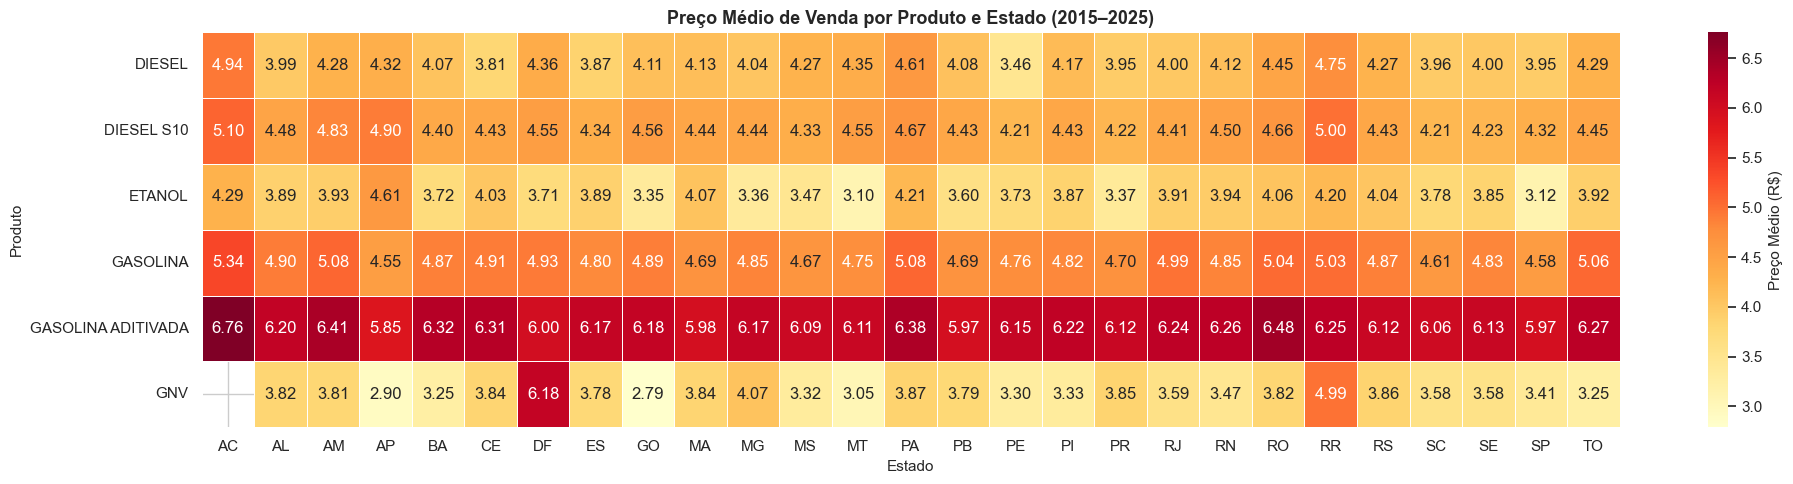

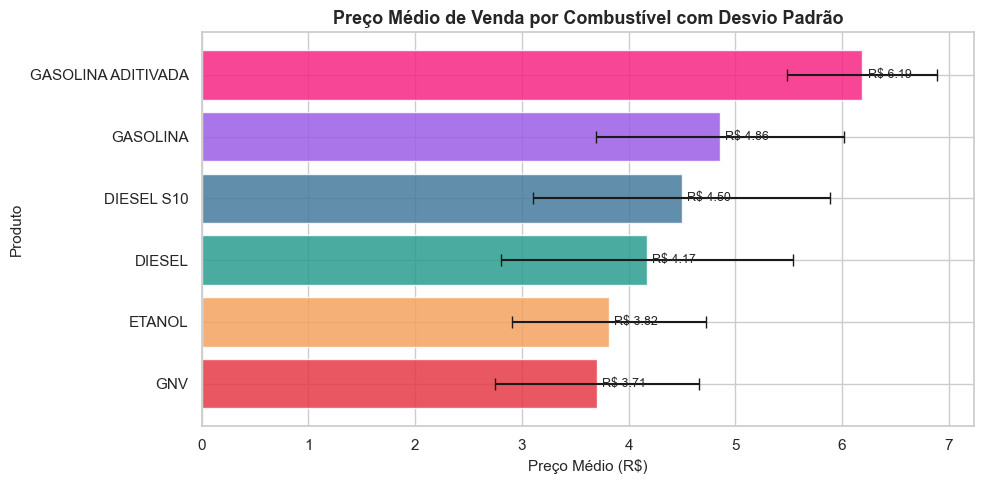


✅ Visualizações geradas com sucesso!


In [ ]:
class VisualizadorDescritivoValorDeVendaPorProduto:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe
        self._configurar_estilo()

    def _configurar_estilo(self):
        sns.set_theme(style="whitegrid", palette="muted")
        plt.rcParams["axes.titlesize"] = 13
        plt.rcParams["axes.labelsize"] = 11

    def _calcular_estatisticas(self):
        return (
            self.dataframe
            .groupby(['Produto', 'Estado - Sigla'])['Valor de Venda']
            .describe()
            .round(2)
        )

    def plotar_heatmap_media_por_estado(self):
        """Heatmap: preço médio por Produto x Estado"""
        estatisticas = self._calcular_estatisticas()
        pivot = estatisticas['mean'].unstack(level='Estado - Sigla')

        fig, ax = plt.subplots(figsize=(20, 5))
        sns.heatmap(
            pivot,
            annot=True,
            fmt='.2f',
            cmap='YlOrRd',
            linewidths=0.4,
            ax=ax,
            cbar_kws={'label': 'Preço Médio (R$)'}
        )
        ax.set_title('Preço Médio de Venda por Produto e Estado (2015–2025)', fontweight='bold')
        ax.set_xlabel('Estado')
        ax.set_ylabel('Produto')
        plt.tight_layout()
        plt.savefig('viz_heatmap_produto_estado.png', dpi=150, bbox_inches='tight')
        plt.show()

    def plotar_barras_media_desvio_por_produto(self):
        """Barras horizontais: média ± desvio padrão por produto"""
        estatisticas = self._calcular_estatisticas()
        resumo = (
            estatisticas[['mean', 'std']]
            .groupby(level='Produto')
            .mean()
            .sort_values('mean', ascending=True)
        )

        fig, ax = plt.subplots(figsize=(10, 5))
        bars = ax.barh(
            resumo.index,
            resumo['mean'],
            xerr=resumo['std'],
            color=['#E63946', '#F4A261', '#2A9D8F', '#457B9D', '#9B5DE5', '#F72585'],
            edgecolor='white',
            capsize=4,
            alpha=0.85
        )
        ax.set_title('Preço Médio de Venda por Combustível com Desvio Padrão', fontweight='bold')
        ax.set_xlabel('Preço Médio (R$)')
        ax.set_ylabel('Produto')

        for bar, val in zip(bars, resumo['mean']):
            ax.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
                    f'R$ {val:.2f}', va='center', fontsize=9)

        plt.tight_layout()
        plt.savefig('viz_barras_media_produto.png', dpi=150, bbox_inches='tight')
        plt.show()

    def gerar_visualizacoes_completas(self):
        self.plotar_heatmap_media_por_estado()
        self.plotar_barras_media_desvio_por_produto()


# Instância e execução
viz_descritivo = VisualizadorDescritivoValorDeVendaPorProduto(dataframe=data_Frame)
viz_descritivo.gerar_visualizacoes_completas()

### 4.2 – Ranking dos Municípios Mais Caros e Mais Baratos por Combustível

Para cada tipo de combustível, são exibidos os **5 municípios com maior preço médio**
e os **5 com menor preço médio** no período de 2015 a 2025.

> Valores nominais, sem ajuste por IPCA.

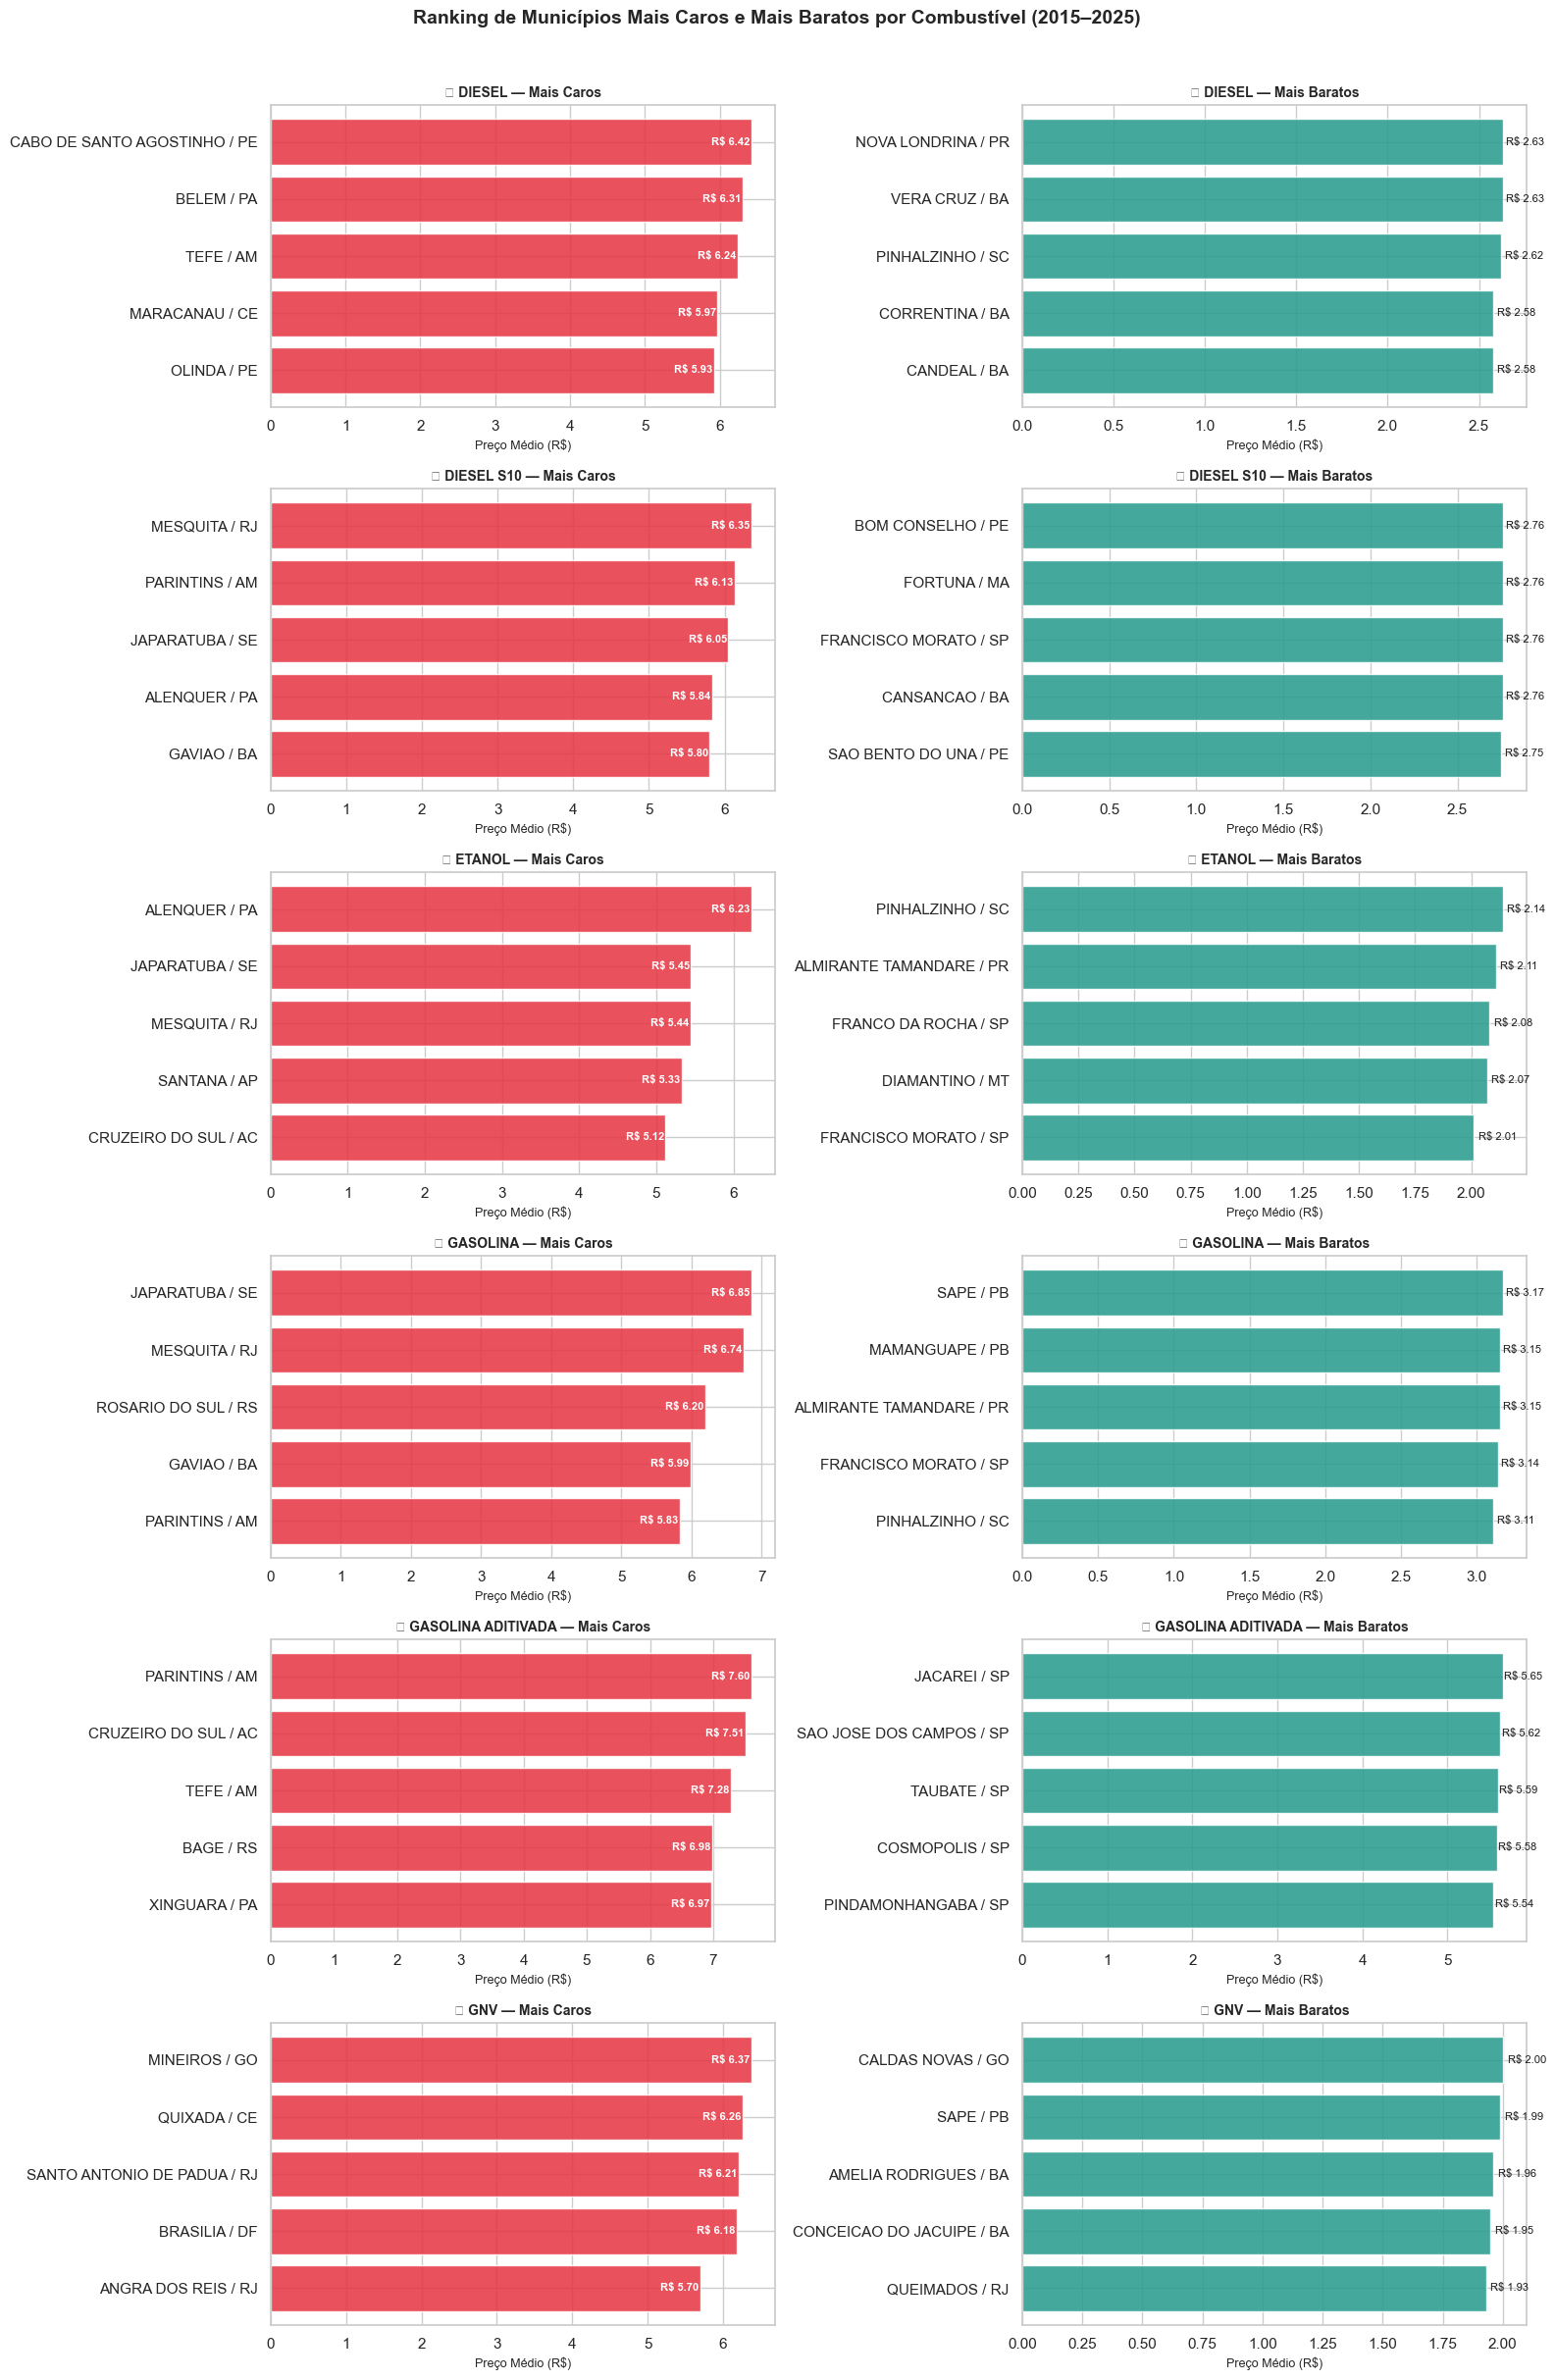

In [9]:
class VisualizadorMunicipiosPorProdutoPrecos:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe
        self._configurar_estilo()

    def _configurar_estilo(self):
        sns.set_theme(style="whitegrid")
        plt.rcParams["axes.titlesize"] = 10
        plt.rcParams["axes.labelsize"] = 9

    def _calcular_media_por_municipio(self):
        return (
            self.dataframe
            .groupby(['Produto', 'Estado - Sigla', 'Municipio'])['Valor de Venda']
            .mean()
            .round(2)
            .reset_index()
        )

    def plotar_ranking_municipios_por_produto(self):
        """Grid único: top 5 mais caros e mais baratos para cada produto"""
        dados = self._calcular_media_por_municipio()
        produtos = sorted(dados['Produto'].unique())
        n = len(produtos)

        fig, axes = plt.subplots(n, 2, figsize=(16, n * 4))
        fig.suptitle('Ranking de Municípios Mais Caros e Mais Baratos por Combustível (2015–2025)',
                     fontsize=14, fontweight='bold', y=1.01)

        for i, produto in enumerate(produtos):
            df_produto = dados[dados['Produto'] == produto].sort_values('Valor de Venda', ascending=False)

            top_caros   = df_produto.head(5).copy()
            top_baratos = df_produto.tail(5).copy()

            top_caros['Label']   = top_caros['Municipio']   + ' / ' + top_caros['Estado - Sigla']
            top_baratos['Label'] = top_baratos['Municipio'] + ' / ' + top_baratos['Estado - Sigla']

            ax_caro   = axes[i, 0]
            ax_barato = axes[i, 1]

            # Mais caros
            ax_caro.barh(top_caros['Label'], top_caros['Valor de Venda'],
                         color='#E63946', edgecolor='white', alpha=0.88)
            ax_caro.set_title(f'🔴 {produto} — Mais Caros', fontweight='bold')
            ax_caro.set_xlabel('Preço Médio (R$)')
            ax_caro.invert_yaxis()
            for j, val in enumerate(top_caros['Valor de Venda']):
                ax_caro.text(val - 0.02, j, f'R$ {val:.2f}',
                             va='center', ha='right', fontsize=8,
                             color='white', fontweight='bold')

            # Mais baratos
            ax_barato.barh(top_baratos['Label'], top_baratos['Valor de Venda'],
                           color='#2A9D8F', edgecolor='white', alpha=0.88)
            ax_barato.set_title(f'🟢 {produto} — Mais Baratos', fontweight='bold')
            ax_barato.set_xlabel('Preço Médio (R$)')
            ax_barato.invert_yaxis()
            for j, val in enumerate(top_baratos['Valor de Venda']):
                ax_barato.text(val + 0.02, j, f'R$ {val:.2f}',
                               va='center', ha='left', fontsize=8, color='#1a1a1a')

        plt.tight_layout()
        plt.savefig('viz_ranking_municipios_todos_produtos.png', dpi=150, bbox_inches='tight')
        plt.show()

    def gerar_visualizacoes_completas(self):
        self.plotar_ranking_municipios_por_produto()


# Instância e execução
viz_municipios = VisualizadorMunicipiosPorProdutoPrecos(dataframe=data_Frame)
viz_municipios.gerar_visualizacoes_completas()

### 4.3 – Evolução Bruta dos Preços dos Combustíveis (2015–2025)

O gráfico abaixo apresenta a evolução do preço médio anual de cada combustível,
acompanhada da faixa entre o menor e o maior preço registrado no período.
Isso permite observar tanto a tendência geral quanto a volatilidade dos preços ao longo dos anos.

> Valores nominais, sem ajuste por IPCA.

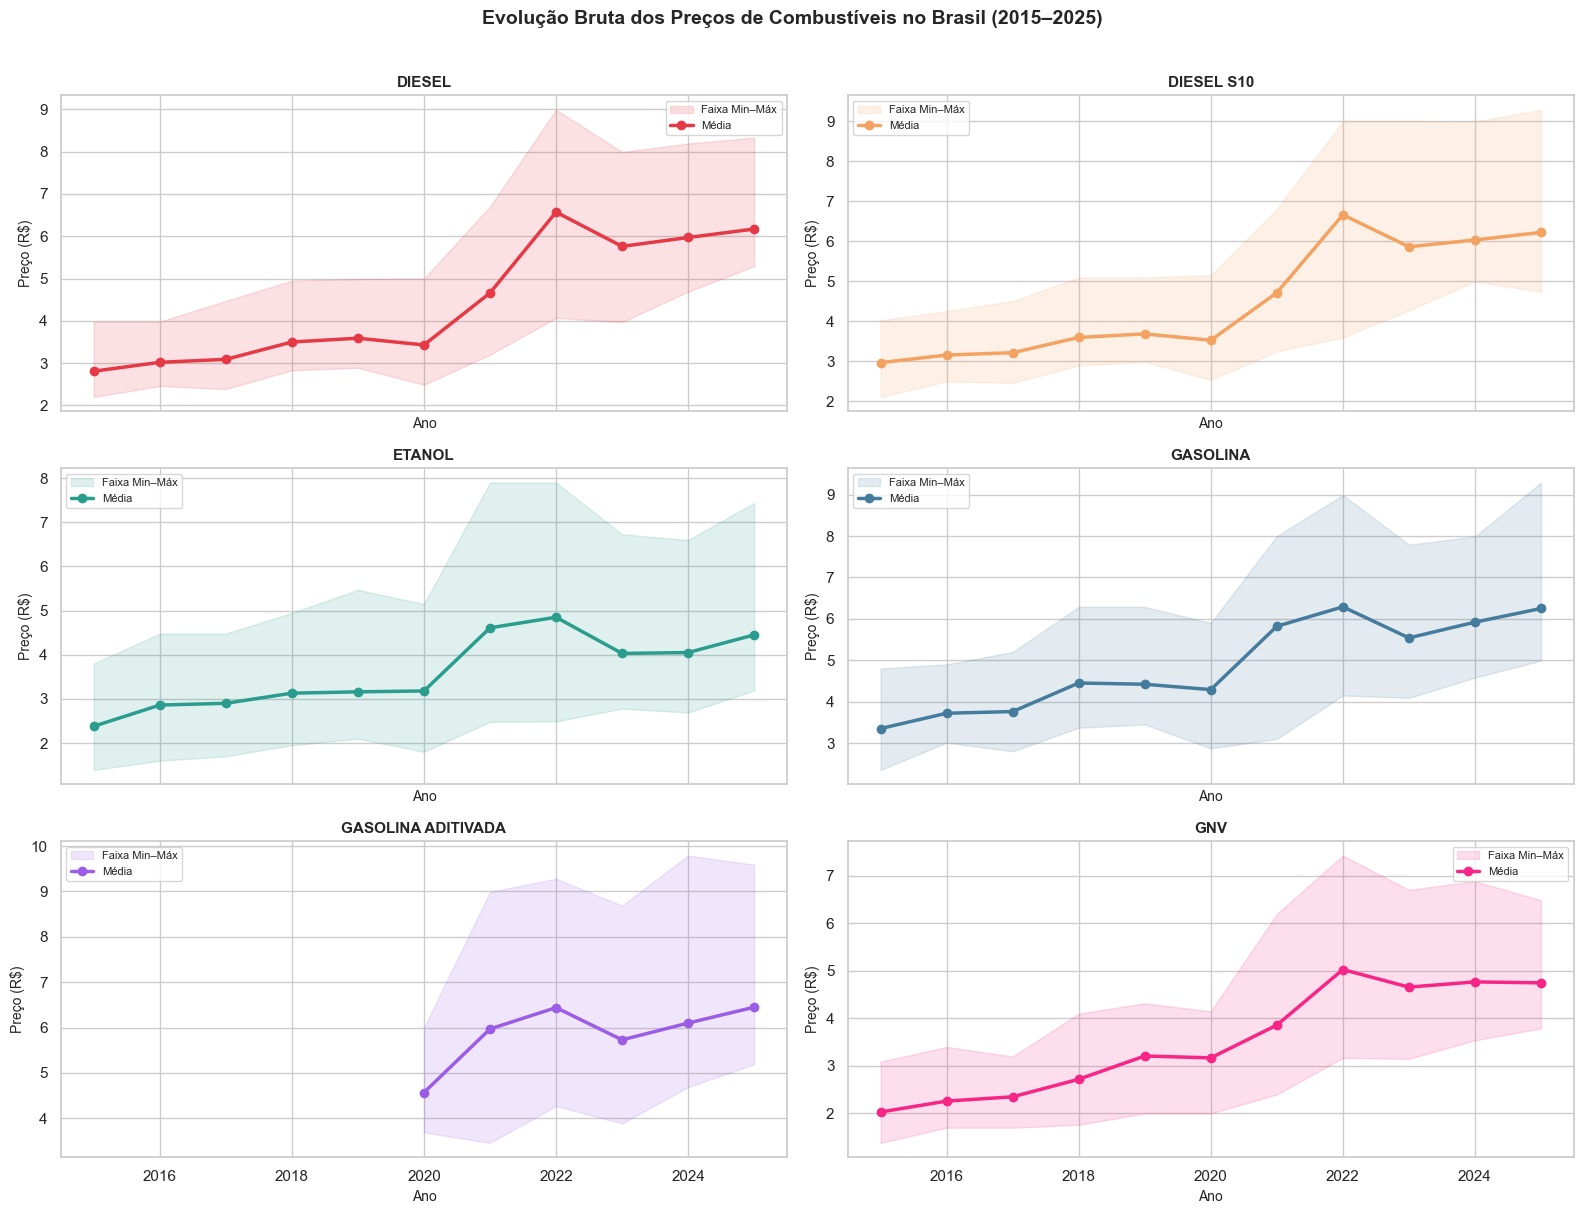

In [35]:
class VisualizadorEvolucaoTemporalPrecos:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe.copy()
        self._preparar_dados()
        self._configurar_estilo()

    def _configurar_estilo(self):
        sns.set_theme(style="whitegrid")
        plt.rcParams["axes.titlesize"] = 11
        plt.rcParams["axes.labelsize"] = 10

    def _preparar_dados(self):
        self.dataframe['Data da Coleta'] = pd.to_datetime(
            self.dataframe['Data da Coleta'], errors='coerce'
        )
        self.dataframe['Ano'] = self.dataframe['Data da Coleta'].dt.year

    def _calcular_evolucao(self):
        return (
            self.dataframe
            .groupby(['Ano', 'Produto'])['Valor de Venda']
            .agg(Media='mean', Min='min', Max='max')
            .round(2)
            .reset_index()
        )

    def plotar_evolucao_temporal(self):
        """Linhas com área sombreada min/max por produto — grid único"""
        dados = self._calcular_evolucao()
        produtos = sorted(dados['Produto'].unique())
        n = len(produtos)

        cores = ['#E63946', '#F4A261', '#2A9D8F', '#457B9D', '#9B5DE5', '#F72585']

        cols = 2
        rows = (n + 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4), sharex=True)
        axes = axes.flatten()

        fig.suptitle('Evolução Bruta dos Preços de Combustíveis no Brasil (2015–2025)',
                     fontsize=14, fontweight='bold', y=1.01)

        for i, produto in enumerate(produtos):
            df_p = dados[dados['Produto'] == produto].sort_values('Ano')
            cor  = cores[i % len(cores)]
            ax   = axes[i]

            # Área sombreada min/max
            ax.fill_between(df_p['Ano'], df_p['Min'], df_p['Max'],
                            alpha=0.15, color=cor, label='Faixa Min–Máx')

            # Linha da média
            ax.plot(df_p['Ano'], df_p['Media'], marker='o', color=cor,
                    linewidth=2.5, label='Média')

            ax.set_title(produto, fontweight='bold')
            ax.set_ylabel('Preço (R$)')
            ax.set_xlabel('Ano')
            ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
            ax.legend(fontsize=8)

        # Remove subplots vazios se número de produtos for ímpar
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.savefig('viz_evolucao_temporal_precos.png', dpi=150, bbox_inches='tight')
        plt.show()

    def gerar_visualizacoes_completas(self):
        self.plotar_evolucao_temporal()


# Instância e execução
viz_evolucao = VisualizadorEvolucaoTemporalPrecos(dataframe=data_Frame)
viz_evolucao.gerar_visualizacoes_completas()

### 4.4 – Evolução dos Preços por Região (2015–2025)

Complementando a análise temporal, o gráfico abaixo segmenta a evolução dos preços
médios por região brasileira, evidenciando que o aumento dos preços não ocorreu
de forma homogênea no país — com diferenças regionais relevantes ao longo do período.

> Valores nominais, sem ajuste por IPCA.

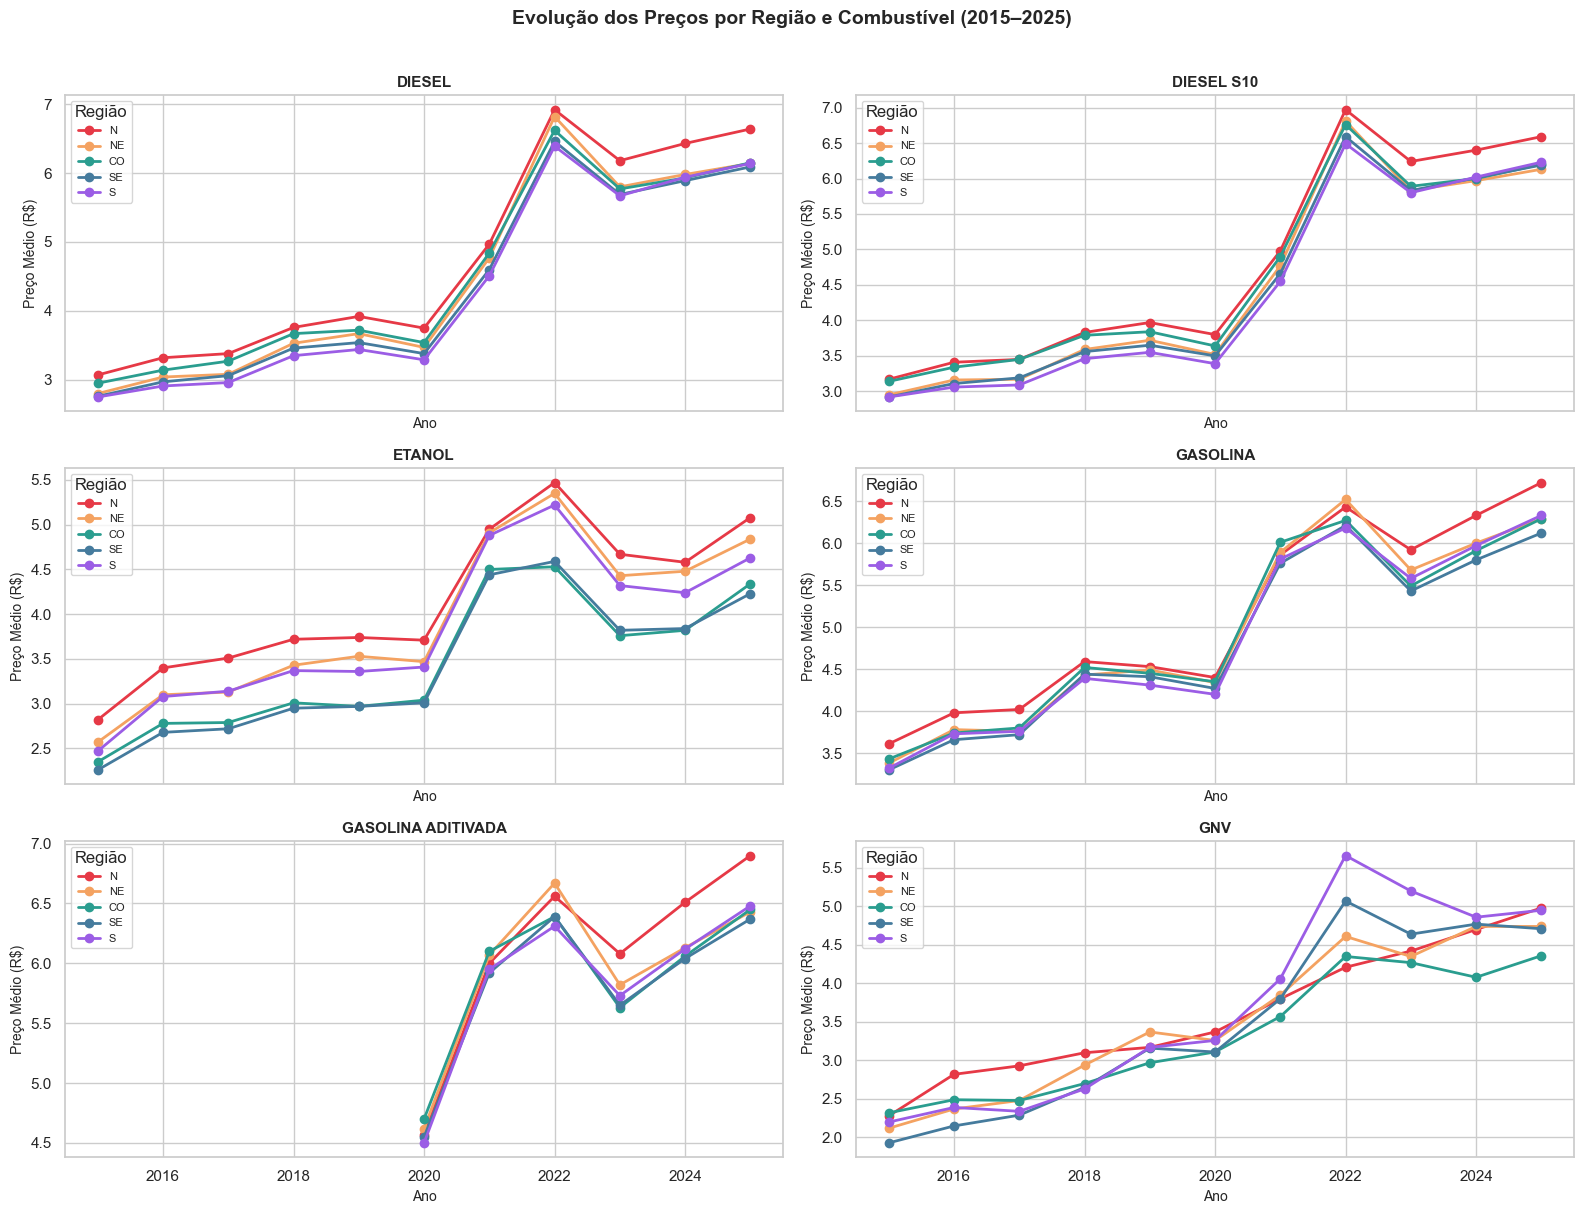

In [36]:
class VisualizadorEvolucaoTemporalPorRegiao:
    def __init__(self, dataframe: pd.DataFrame):
        self.dataframe = dataframe.copy()
        self._preparar_dados()
        self._configurar_estilo()

    def _configurar_estilo(self):
        sns.set_theme(style="whitegrid")
        plt.rcParams["axes.titlesize"] = 11
        plt.rcParams["axes.labelsize"] = 10

    def _preparar_dados(self):
        self.dataframe['Data da Coleta'] = pd.to_datetime(
            self.dataframe['Data da Coleta'], errors='coerce'
        )
        self.dataframe['Ano'] = self.dataframe['Data da Coleta'].dt.year

    def _calcular_evolucao_por_regiao(self):
        return (
            self.dataframe
            .groupby(['Ano', 'Produto', 'Regiao - Sigla'])['Valor de Venda']
            .mean()
            .round(2)
            .reset_index()
        )

    def plotar_evolucao_por_regiao(self):
        """Grid: uma linha por região, um subplot por produto"""
        dados = self._calcular_evolucao_por_regiao()
        produtos = sorted(dados['Produto'].unique())
        n = len(produtos)

        cores_regioes = {
            'N':  '#E63946',
            'NE': '#F4A261',
            'CO': '#2A9D8F',
            'SE': '#457B9D',
            'S':  '#9B5DE5'
        }

        cols = 2
        rows = (n + 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4), sharex=True)
        axes = axes.flatten()

        fig.suptitle('Evolução dos Preços por Região e Combustível (2015–2025)',
                     fontsize=14, fontweight='bold', y=1.01)

        for i, produto in enumerate(produtos):
            ax = axes[i]
            df_p = dados[dados['Produto'] == produto]

            for regiao, cor in cores_regioes.items():
                df_r = df_p[df_p['Regiao - Sigla'] == regiao].sort_values('Ano')
                if df_r.empty:
                    continue
                ax.plot(df_r['Ano'], df_r['Valor de Venda'],
                        marker='o', color=cor, linewidth=2,
                        label=regiao)

            ax.set_title(produto, fontweight='bold')
            ax.set_ylabel('Preço Médio (R$)')
            ax.set_xlabel('Ano')
            ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
            ax.legend(title='Região', fontsize=8)

        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.savefig('viz_evolucao_temporal_por_regiao.png', dpi=150, bbox_inches='tight')
        plt.show()

    def gerar_visualizacoes_completas(self):
        self.plotar_evolucao_por_regiao()


# Instância e execução
viz_evolucao_regiao = VisualizadorEvolucaoTemporalPorRegiao(dataframe=data_Frame)
viz_evolucao_regiao.gerar_visualizacoes_completas()

## 5. Identificação de Problemas nos Dados

Durante a análise exploratória dos dados, foram identificados alguns desafios e limitações que podem impactar tanto a interpretação dos resultados quanto o desempenho de modelos preditivos.

### 5.1 Desbalanceamento de Dados

Observa-se um desbalanceamento significativo na distribuição dos dados, tanto em relação aos tipos de combustível quanto às regiões geográficas:

* **Tipo de combustível:**
  A categoria *gasolina aditivada* só passa a aparecer com frequência a partir de 2020, o que pode comprometer análises temporais e gerar viés em modelos que considerem períodos anteriores.

* **Distribuição regional:**
  Há uma forte concentração de dados na região Sudeste, enquanto regiões como Norte e Centro-Oeste possuem menor representatividade:


In [ ]:
regiao_dist = (
    data_Frame['Regiao - Sigla']
    .value_counts(normalize=True) * 100
).round(2)

regiao_df = regiao_dist.reset_index()
regiao_df.columns = ['Região', 'Representatividade (%)']

regiao_df = regiao_df.sort_values(by='Representatividade (%)', ascending=False)
regiao_df.reset_index(drop=True, inplace=True)

regiao_df.style.hide(axis='index')

: 


Esse desbalanceamento pode levar o modelo a aprender padrões mais representativos de determinadas regiões, reduzindo sua capacidade de generalização.


---

### 5.2 Ausência de Correção Monetária

Os valores de venda dos combustíveis não estão ajustados pela inflação ao longo do tempo.

Considerando que o período analisado (2015–2025) inclui variações econômicas significativas, a comparação direta dos preços pode levar a interpretações equivocadas. Idealmente, os valores deveriam ser corrigidos por índices inflacionários (como IPCA) para permitir análises mais consistentes.

---

### 5.3 Presença de Outliers e Eventos Exógenos

Foram identificados valores atípicos (outliers) que não necessariamente representam erros, mas sim reflexos de eventos econômicos e sociais relevantes, tais como:

* **2016:** Crise econômica no Brasil
* **2018:** Greve dos caminhoneiros
* **2020:** Pandemia de COVID-19
* **2022:** Alta global nos preços dos combustíveis

Esses eventos geram picos ou quedas abruptas nos preços, podendo impactar negativamente modelos preditivos caso não sejam tratados adequadamente.

---

### 5.5 Granularidade Temporal e Espacial

Os dados são coletados semanalmente e em diferentes municípios, o que pode gerar:

* Variações locais significativas (diferenças entre cidades);
* Ruídos temporais devido à frequência de coleta;
* Dificuldade em capturar tendências mais suaves sem algum tipo de agregação (ex.: média mensal).


---

### 5.4 Dados Ausentes

O dataset apresenta valores ausentes em algumas colunas. No entanto:

* A maioria dos dados faltantes está associada a variáveis de menor relevância (ex.: campos complementares);
* As variáveis principais para modelagem (como preço, data e localização) apresentam boa completude.

Mesmo assim, é importante avaliar cuidadosamente o impacto desses dados ausentes antes de aplicar técnicas de imputação ou remoção.

In [ ]:
missing = (data_Frame.isnull().sum() / len(data_Frame)) * 100
missing = missing[missing > 0].sort_values(ascending=False)

missing = missing.round(2)

missing.sort_values().plot(kind='barh')
plt.title("Percentual de valores ausentes por coluna (2015–2025)")
plt.xlabel("% de valores nulos")
plt.show()


---

### Valores Ausentes na Variável Temporal

Foi identificado um volume significativo de valores ausentes na variável **`Data da Coleta`**.

Observa-se que esses registros não estão associados a nenhum período específico, o que **impossibilita sua distribuição ao longo do tempo** e compromete análises baseadas em séries temporais.

Dessa forma:

* Esses dados **não podem ser utilizados em análises temporais**;
* É necessário **avaliar estratégias de tratamento**, como:

  * Remoção das instâncias;
  * Ou utilização apenas em análises não temporais.

> A ausência da variável temporal representa uma limitação relevante do dataset, impactando diretamente a modelagem preditiva baseada em séries temporais.

---

### Ranking de Valores Ausentes por Coluna

Abaixo está o ranking das colunas com maior quantidade de dados faltantes, permitindo identificar quais variáveis demandam maior atenção durante o processo de tratamento e preparação dos dados.

---


In [ ]:
missing_table = pd.DataFrame({
    'Valores Faltantes': data_Frame.isnull().sum(),
    'Percentual (%)': (data_Frame.isnull().sum() / len(data_Frame)) * 100
})

missing_table = missing_table[missing_table['Valores Faltantes'] > 0]

# Remover coluna derivada
missing_table = missing_table.drop(index='Ano', errors='ignore')

missing_table = missing_table.sort_values(by='Valores Faltantes', ascending=False)

missing_table


---

## Conclusão

Ao longo deste notebook, foram realizadas etapas de análise exploratória e identificação de padrões relevantes no comportamento dos preços de combustíveis no Brasil.

A partir dos resultados obtidos, foi possível compreender melhor a estrutura dos dados, suas limitações e os principais desafios envolvidos, como a presença de valores ausentes e desbalanceamentos.

Essas análises são fundamentais para orientar as próximas etapas do projeto, especialmente no desenvolvimento de modelos preditivos mais robustos e confiáveis.

---

## Próximos Passos

* Tratamento de dados faltantes
* Engenharia de features
* Construção e avaliação de modelos preditivos
* Análise de desempenho e validação

---

> Este notebook representa a etapa inicial de exploração e compreensão dos dados, servindo como base para as fases posteriores do projeto.